<a href="https://colab.research.google.com/github/nauzleyabedini/Clinical-Note-Evaluation/blob/main/Clinical_Note_Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Clinical Documentation Evaluation Harness:

This project presents a robust harness for the comprehensive evaluation of AI-generated clinical notes against established quality, accuracy, and compliance standards. Leveraging advanced Large Language Models (LLMs) and quantitative metrics, this system addresses critical challenges in healthcare AI, such as hallucination detection, clinical accurac, and billing compliance.

## Project Overview

The harness is designed to meticulously audit AI-generated clinical documentation. It integrates multiple frontier LLMs to simulate real-world auditing scenarios and measure the efficiency gains and potential burdens introduced by AI in clinical settings. This project showcases expertise in:

*   **Multi-LLM Integration & Orchestration:** Seamlessly working with and evaluating outputs from diverse LLM providers, including managing model-specific API nuances.
*   **Custom Prompt Engineering for Clinical Integrity:** Developing structured, domain-specific, and rigorously tested prompts for highly accurate and consistent evaluations, with **explicit JSON schema enforcement** tailored to clinical criteria.
*   **Robust API Handling:** Implementing advanced retry logic with exponential backoff and fine-tuning model parameters (e.g., `max_tokens`, `temperature`) to ensure resilience, reliability, and deterministic output from various APIs.
*   **Quantitative Performance Metrics with Clinical Domain Expertise:** Defining and applying measurable metrics for clinical accuracy, compliance (HCC capture, ICD-10 specificity), and safety, informed by deep clinical understanding.
*   **Healthcare AI Application:** Addressing a critical need in clinical AI development for rigorous validation and continuous improvement of documentation systems, directly contributing to safe and effective AI deployment in healthcare.

## Methodology

### AI Note Generation

The Gemini API (`gemini-3.6-flash`) and rigorously refined system prompt are leveraged to generate AI clinical note from a subset of outpatient patient-clinician conversation transcripts derived from the [ACI-BENCH dataset](https://arxiv.org/abs/2306.02022).

**AI Note Generation Process (Google Gemini):**

*   **Few-Shot Prompting:** The Gemini API (`gemini-3.6-flash`) is used to generate the initial AI draft notes. The prompt incorporates domain-specific few-shot examples to guide the model towards the desired output format and content, emphasizing clinical integrity, compliance, and safety.
*   **Post-Processing for Structure:** A custom Python function is applied post-generation to enforce a strict, predefined clinical note structure (e.g., 'CHIEF COMPLAINT', 'HISTORY OF PRESENT ILLNESS', 'REVIEW OF SYSTEMS', 'PHYSICAL EXAM', 'RESULTS', 'ASSESSMENT AND PLAN'). This programmatic step uses regular expressions to parse and reconstruct the note, ensuring all required headings are present and content is correctly organized, even if initial LLM output deviates slightly.

### AI Note Evaluation Against Ground Truth Transcripts & Clinician-Vetted Notes

The quality of AI-generated draft notes are compared against the original doctor-patient transcripts and a "Gold Standard Note," simulating an expert Clinical Documentation Integrity (CDI) audit using two distinct LLMs (OpenAI `gpt-4o-mini` and Anthropic `claude-sonnet-5`) acting as independent auditors.

**Modular Evaluation Approach reflecting Clinical Domain Expertise:**
The evaluation of these AI-generated notes is modular, grouping evaluation criteria into three core domains, each designed to assess specific aspects of clinical documentation from an expert perspective. A modular evaluation harness was used to allow more flexibility in fine-tuning and to limit computational demands:

1.  **Clinical Fact Grounding:** This module rigorously assesses the AI note's fidelity to the original patient-doctor transcript. It measures:
    *   **Transcript Fidelity (Score 1-4):** How accurately the AI note reflects the information in the transcript.
        *   Score 4 (Fully Accurate): Every clinical assertion in the note aligns with explicit statements or necessary clinical deductions from the transcript.
        *   Score 3 (Minor Inaccuracy): Contains trivial misstatements that do not alter clinical context.
        *   Score 2 (Moderate Distortion): Misrepresents patient history, severity, or examination details.
        *   Score 1 (Major Factual Error): Directly contradicts facts established in the transcript.
    *   **Hallucinations (Count & Severity 1-3):** Identifies any information in the AI note not grounded in the transcript.
        *   `hallucinations_count`: Number of hallucinations (0, 1, 2, ...).
        *   `hallucinations_severity_score`: Score 3 (No hallucinations), Score 2 (Low severity), Score 1 (High severity).
    *   **Critical Omissions (Score 1-3):** Detects critical clinical information from the transcript omitted from the AI note.
        *   Score 3 (No Critical Omissions): No critical omissions present.
        *   Score 2 (Low severity): Low stakes omissions that do not have the potential to cause harm.
        *   Score 1 (High severity): High stakes omissions with potential for harm.

2.  **Compliance & Billing:** This module focuses on the adherence to coding and regulatory standards by comparing the AI Note against both the Gold Standard Note and the Transcript:
    *   **HCC Compliance via MEAT Criteria (Ratio & Pass/Fail):** For chronic conditions, verifies MEAT (Monitor, Evaluate, Assess, Treat) documentation.
        *   `hcc_compliance_ratio_percentage`: (float 0.0-1.0).
        *   `hcc_pass_fail`: (boolean) based on a compliance ratio threshold of >= 0.8.
    *   **ICD-10 Specificity (Scale 1-3):** Assesses the specificity of implied or explicit ICD-10 codes.
        *   Score 3 (High Specificity): Captures maximum clinical detail.
        *   Score 2 (Unspecified): Uses generic terms when specifics are available.
        *   Score 1 (Invalid): Codes unconfirmed or undocumented conditions.
    *   **Clinical Validation (Scale 1-3):** Assesses if clinical statements and diagnoses are clinically sound and supported.
        *   Score 3 (Compliant): Strong clinical indicators support all documented diagnoses.
        *   Score 2 (Query Likely): Diagnosis documented but lacking supporting clinical data.
        *   Score 1 (Upcoding / Unsubstantiated): High-risk diagnosis asserted without evidence.

3.  **Quality, Style & Safety:** This module examines the overall quality, adherence to style guidelines, and potential safety risks within the AI note, using both the Gold Standard Note and Transcript for context. It covers, incorporating **critical safety flags** and qualitative assessment skills:
    *   **Note Structure & Organization (0-5):** Evaluate adherence to outpatient note structure, readability, and clarity.
        *   Score 1 (Unacceptable) to Score 5 (Excellent), with detailed rubrics for each level.
    *   **Safety Risk Tier (Score 1-4):** Identify potential patient safety risks.
        *   Score 4 (None): Zero safety concerns.
        *   Score 3 (Low): Minor ambiguity.
        *   Score 2 (Moderate): Potential for minor clinical misunderstanding.
        *   Score 1 (Critical): Risk of patient harm.
    *   **`overall_key_findings`:** A string summary of overall errors or strengths across all modules.

**Output:** Strictly structured JSON containing quantifiable scores for each domain and `overall_key_findings`, rigorously enforced through prompt engineering and `response_format` settings.


## Key Features & Technical Highlights

*   **Domain-Specific Data Handling:** Utilizes the [ACI-BENCH dataset](https://arxiv.org/abs/2306.02022), demonstrating experience with specialized healthcare datasets and understanding of clinical data nuances.
*   **Flexible LLM Integration with Nuance Handling:** Designed to easily incorporate and compare performance across various generative AI models, including explicit handling of Anthropic's `TextBlock` responses and setting `temperature=0.0` for deterministic JSON output.
*   **Strict Structured Output Parsing:** Ensures reliable extraction of complex evaluation metrics from LLM responses via explicit JSON schema enforcement and robust post-processing.
*   **Advanced Error Tolerance & Recovery:** Implements robust error handling, including API-specific retry mechanisms with exponential backoff, and strategies to mitigate `JSONDecodeError` by optimizing `max_tokens` and `temperature` for consistent LLM output.
*   **Iterative Fine-Tuning of Evaluation Logic:** The modular design facilitates **iterative refinement and optimization** of individual evaluation criteria and prompts, allowing for continuous improvement of the harness's precision and recall in identifying documentation issues.
*   **Quantitative Analysis for Actionable Clinical Impact:** Focuses on generating measurable data points to inform AI model improvements and assess clinical impact, providing actionable insights for clinical AI development by directly linking technical metrics to **clinical outcomes and compliance standards**.

## Results

https://colab.research.google.com/drive/1AMr9MxKrRmh8ff5GPfQLyFLvm-aTnABi#scrollTo=1f9d0f75&line=1&uniqifier=1


In [1]:
#-------------------------------------------------------------------------------
#                                OVERALL EVALUATION APPROACH
#-------------------------------------------------------------------------------
#                         ┌─────────────────────────────────────────┐
#                         │       DOCTOR - PATIENT DIALOGUE         |
#                         │            ACI-BENCH Dataset            |
#                         └────────────────────┬────────────────────┘
#                                              │
#                                              ▼
#                         ┌─────────────────────────────────────────┐
#                         |       AMBIENT AI NOTE GENERATION        |
#                         │              (Gemini API)               |
#                         └────────────────────┬────────────────────┘
#                                              │
#                                              ▼
#                         ┌─────────────────────────────────────────┐
#                         │    EVALUATION AGAINST TRANSCRIPT &      |
#                         |         GOLD STANDARD NOTES             |
#                         │        (OpenAI and Anthropic APIs)      |
#                         └────────────────────┬────────────────────┘
#                                              │
#                                              ▼
#               ┌──────────────────────────────┼──────────────────────────────┐
#               ▼                              ▼                              ▼
    # ┌──────────────────────────┐   ┌──────────────────────────┐   ┌──────────────────────────┐
    # │  Module 1: Clinical Fact │   │ Module 2: Compliance &   │   │   Module 3: Quality,     │
    # │        Grounding         │   │         Billing          │   │      Style & Harm        │
    # ├──────────────────────────┤   ├──────────────────────────┤   ├──────────────────────────┤
    # │ • Transcript Fidelity    │   │ • MEAT Compliance        │   │ • Structure & Org.       │
    # │ • Hallucination Counts   │   │ • ICD-10 Specificity     │   │
    # │ • Critical Omissions     │   │ • Clinical Validation    │   │ • Safety Risk Tier       │
    # └────────────┬─────────────┘   └────────────┬─────────────┘   └────────────┬─────────────┘
    #              │                              │                              │
    #              └──────────────────────────────┼──────────────────────────────┘
    #                                             ▼
    #                                [ Evaluation Aggregator ]
    #                             (Combines JSON outputs into
    #                              a unified CDI score card)

In [2]:
#-----------------------------
#       SET UP APIs
#-----------------------------

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

!pip install anthropic
!pip install -U google-generativeai # Install or update the google-generativeai package
from google.colab import userdata
from anthropic import Anthropic
import google.generativeai as genai # Reverted import for Gemini to original style
from openai import OpenAI, RateLimitError, APIError # Import specific OpenAI error types
from anthropic import APIStatusError, OverloadedError # Only import specific Anthropic error types needed
from anthropic.types import TextBlock # Added TextBlock import for handling Anthropic responses
from google.api_core.exceptions import GoogleAPIError # Import GoogleAPIError for Gemini

# Map Colab secrets to system environment variables
os.environ["ANTHROPIC_API_KEY"] = userdata.get('AnthropicClinDocEvalAPIKey')
os.environ["OPENAI_API_KEY"] = userdata.get('OpenAIClinDocEvalAPIKey')
os.environ["GEMINI_API_KEY"] = userdata.get('Gemini_Clin_Doc_Eval_APIKey')

# Configure Gemini API key
genai.configure(api_key=os.environ["GEMINI_API_KEY"]) # Keep global configure

# Initialize the clients
anthropic_client = Anthropic()
openai_client = OpenAI()
gemini_model = genai.GenerativeModel('gemini-3.6-flash') # Removed api_key from constructor, relying on global configure

# Test Anthropic with retry logic
max_retries_anthropic = 5
base_delay_anthropic = 1 # seconds
anthropic_response = None

for i in range(max_retries_anthropic):
    try:
        anthropic_response = anthropic_client.messages.create(
            model="claude-sonnet-5", # Corrected model name based on error suggestion
            max_tokens=1000,
            messages=[{"role": "user", "content": "Say hello!"}]
        )
        print("Anthropic says:", anthropic_response.content[0].text)
        break # If successful, break the loop
    except OverloadedError as e:
        if i < max_retries_anthropic - 1:
            delay = base_delay_anthropic * (2 ** i) + random.uniform(0, 1) # Exponential backoff with jitter
            print(f"Anthropic API overloaded. Retrying in {delay:.2f} seconds...")
            time.sleep(delay)
        else:
            print(f"Max retries reached. Still encountering OverloadedError: {e}")
            # If you want to raise an error after max retries:
            # raise # Re-raise the exception if max retries are exceeded
            print("Skipping Anthropic API call due to persistent overload.")
            break # Exit loop if Anthropic persistently overloaded
    except APIStatusError as e:
        print(f"Anthropic API error: {e}")
        raise # Re-raise other API errors immediately

# Test OpenAI with retry logic
max_retries_openai = 5
base_delay_openai = 1 # seconds
openai_response = None

for i in range(max_retries_openai):
    try:
        openai_response = openai_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": "Say hello!"}]
        )
        print("OpenAI says:", openai_response.choices[0].message.content)
        break # If successful, break the loop
    except (RateLimitError, APIError) as e:
        if i < max_retries_openai - 1:
            delay = base_delay_openai * (2 ** i) + random.uniform(0, 1) # Exponential backoff with jitter
            print(f"OpenAI API error ({type(e).__name__}). Retrying in {delay:.2f} seconds...")
            time.sleep(delay)
        else:
            print(f"Max retries reached. Still encountering OpenAI API error: {e}")
            raise # Re-raise the exception if max retries are exceeded

# Test Gemini with retry logic
max_retries_gemini = 5
base_delay_gemini = 1 # seconds
gemini_response = None

for i in range(max_retries_gemini):
    try:
        gemini_response = gemini_model.generate_content("Say hello!")
        print("Gemini says:", gemini_response.text)
        break # If successful, break the loop
    except GoogleAPIError as e: # Changed genai.APIError to GoogleAPIError
        if i < max_retries_gemini - 1:
            delay = base_delay_gemini * (2 ** i) + random.uniform(0, 1) # Exponential backoff with jitter
            print(f"Gemini API error ({type(e).__name__}). Retrying in {delay:.2f} seconds...")
            time.sleep(delay)
        else:
            print(f"Max retries reached. Still encountering Gemini API error: {e}")
            raise # Re-raise the exception if max retries are exceeded

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Anthropic says: # Hello! 👋

Nice to meet you! I'm here and ready to help with whatever you need. Whether it's answering questions, brainstorming ideas, helping with writing, solving problems, or just having a conversation, I'm happy to assist.

What can I help you with today?
OpenAI says: Hello! How can I assist you today?
Gemini says: Hello! How can I help you today?


In [3]:
#-----------------------------
  #SET UP ACI-BENCH DATASET
#-----------------------------

# Load the dataset directly from GitHub
url = "https://raw.githubusercontent.com/microsoft/clinical_visit_note_summarization_corpus/refs/heads/main/data/aci-bench/challenge_data/train.csv"
df = pd.read_csv(url)

# View basic dataset information
print(f"Total notes available: {len(df)}")
print("Columns in dataset:", df.columns.tolist())
print("Transcript source types:", df['dataset'].value_counts())

# Use all available notes (67 notes) for a complete evaluation
sample_df = df.copy()
print(f"Successfully loaded {len(sample_df)} encounter records.")

# Display the first transcript snippet
print("\n--- SAMPLE TRANSCRIPT SNIPPET (Note #1) ---")
print(sample_df['note'].iloc[0][:300] + "...")

Total notes available: 67
Columns in dataset: ['dataset', 'encounter_id', 'dialogue', 'note']
Transcript source types: dataset
aci           35
virtassist    20
virtscribe    12
Name: count, dtype: int64
Successfully loaded 67 encounter records.

--- SAMPLE TRANSCRIPT SNIPPET (Note #1) ---
CHIEF COMPLAINT

Annual exam.

HISTORY OF PRESENT ILLNESS

Martha Collins is a 50-year-old female with a past medical history significant for congestive heart failure, depression, and hypertension who presents for her annual exam. It has been a year since I last saw the patient.

The patient has bee...


In [4]:
import google.generativeai as genai

#-------------------------------------------------------
# PHASE 1: GENERATE GEMINI AI DRAFT NOTES
#-------------------------------------------------------

def gem_ai_note(transcript):
    """
    Uses Gemini to generate an initial AI draft note grounded in the transcript.
    This note is designed to be compliant, accurate, and safe according to outpatient note standards.
    """
    system_prompt = """You are an AI assistant specialized in clinical documentation generation and integrity.
    Your task is to generate a comprehensive, accurate, compliant, and safe outpatient note grounded in the included patient-doctor transcript.
    Ensure the note is compliant with clinical standards, avoids hallucinations and omissions, and strictly grounds all details in the transcript.

### GENERATION REQUIREMENTS:
CLINICAL INTEGRITY:
1.  **Transcript Fidelity:** Include only information explicitly stated or clearly implied by the transcript. Strictly avoid adding external knowledge, fabrications, or interpretations not supported by the dialogue.
2.  **Style and Structure:** Structure the note as an outpatient note, with each section as a new paragraph and the following headings: 'CHIEF COMPLAINT,' 'HISTORY OF PRESENT ILLNESS,' 'REVIEW OF SYSTEMS,' 'PHYSICAL EXAM,' 'RESULTS,' and 'ASSESSMENT AND PLAN.' ENSURE ALL THE FOLLOWING HEADINGS ARE PRESENT IN THE OUTPUT, EVEN IF THE SECTION REMAINS BLANK. Avoid repetition of information in different sections. Be comprehensive and concise. Do not include an official physician sign-off line as this is an initial draft.
3.  **Completeness (as per transcript):** Capture all relevant clinical information discussed in the transcript.
4.  **Outpatient Standard:** Generate a note suitable for an outpatient setting.
COMPLIANCE:
5.  **HCC:** For every chronic condition listed in the Assessment/Plan, document at least one MEAT action is documented:
    Monitor (signs, symptoms, test results).
    Evaluate (test results, medication response).
    Assess (status, progress, stability).
    Treat (medications, therapies, referrals).
6.  **ICD-10 Codes:** Use correct ICD-10 codes based on information provided in the transcript.
SAFETY:
**Risk Assessment:** Cross-check and correct for any mistated facts or medical errors that could lead to patient safety events or patient harms. Flag any concerns for clinician review and mark the item.
Return ONLY the AI-generated draft clinical note, formatted as follows:

### EXAMPLE OUTPUT FORMAT:
CHIEF COMPLAINT
[Patient's chief complaint, e.g., 'Annual physical examination.']

HISTORY OF PRESENT ILLNESS
[Relevant history, e.g., 'Mrs. Smith is a 45-year-old female presenting for her annual physical...']

REVIEW OF SYSTEMS
[Review of systems findings, e.g., 'Constitutional: No fever or chills.']

PHYSICAL EXAM
[Physical exam findings, e.g., 'General: Well-appearing, no acute distress.' Include vital signs if available.]

RESULTS
[Relevant test results, e.g., 'Labs: CBC within normal limits.']

ASSESSMENT AND PLAN
[Assessment and plan, e.g., '1. Hypertension (I10): Continue Lisinopril. Monitor BP.']
"""

    user_prompt = f"""### ENCOUNTER TRANSCRIPT:
{transcript}

Please generate the initial AI draft clinical note now:"""

    # Call Gemini API
    response = gemini_model.generate_content(
        contents=f"{system_prompt}\n\n{user_prompt}"
    )
    return response.text.strip()

In [5]:
gem_ai_notes_generated = []

print("\n--- Generating Gemini AI Draft Notes ---")
for i in range(len(sample_df)):
    transcript = sample_df['dialogue'].iloc[i]

    print(f"Generating AI Draft Note for Sample {i+1}...")
    generated_note = gem_ai_note(transcript)
    gem_ai_notes_generated.append(generated_note)

sample_df['gem_ai_notes_generated'] = gem_ai_notes_generated
display(sample_df[['encounter_id', 'dialogue', 'note', 'gem_ai_notes_generated']].head())


--- Generating Gemini AI Draft Notes ---
Generating AI Draft Note for Sample 1...
Generating AI Draft Note for Sample 2...
Generating AI Draft Note for Sample 3...
Generating AI Draft Note for Sample 4...
Generating AI Draft Note for Sample 5...
Generating AI Draft Note for Sample 6...
Generating AI Draft Note for Sample 7...


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1010.98ms


Generating AI Draft Note for Sample 8...
Generating AI Draft Note for Sample 9...
Generating AI Draft Note for Sample 10...
Generating AI Draft Note for Sample 11...
Generating AI Draft Note for Sample 12...
Generating AI Draft Note for Sample 13...
Generating AI Draft Note for Sample 14...
Generating AI Draft Note for Sample 15...
Generating AI Draft Note for Sample 16...
Generating AI Draft Note for Sample 17...
Generating AI Draft Note for Sample 18...
Generating AI Draft Note for Sample 19...
Generating AI Draft Note for Sample 20...
Generating AI Draft Note for Sample 21...
Generating AI Draft Note for Sample 22...


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1340.22ms


Generating AI Draft Note for Sample 23...


...

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1314.77ms


Generating AI Draft Note for Sample 35...
Generating AI Draft Note for Sample 36...
Generating AI Draft Note for Sample 37...
Generating AI Draft Note for Sample 38...
Generating AI Draft Note for Sample 39...
Generating AI Draft Note for Sample 40...
Generating AI Draft Note for Sample 41...
Generating AI Draft Note for Sample 42...
Generating AI Draft Note for Sample 43...
Generating AI Draft Note for Sample 44...


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 809.76ms


Generating AI Draft Note for Sample 45...
Generating AI Draft Note for Sample 46...
Generating AI Draft Note for Sample 47...
Generating AI Draft Note for Sample 48...
Generating AI Draft Note for Sample 49...
Generating AI Draft Note for Sample 50...
Generating AI Draft Note for Sample 51...
Generating AI Draft Note for Sample 52...
Generating AI Draft Note for Sample 53...
Generating AI Draft Note for Sample 54...
Generating AI Draft Note for Sample 55...
Generating AI Draft Note for Sample 56...
Generating AI Draft Note for Sample 57...
Generating AI Draft Note for Sample 58...
Generating AI Draft Note for Sample 59...
Generating AI Draft Note for Sample 60...
Generating AI Draft Note for Sample 61...
Generating AI Draft Note for Sample 62...
Generating AI Draft Note for Sample 63...
Generating AI Draft Note for Sample 64...
Generating AI Draft Note for Sample 65...
Generating AI Draft Note for Sample 66...
Generating AI Draft Note for Sample 67...


,encounter_id,dialogue,note,gem_ai_notes_generated
0,D2N001,"[doctor] hi , martha . how are you ?\n[patient...",CHIEF COMPLAINT\n\nAnnual exam.\n\nHISTORY OF ...,CHIEF COMPLAINT\nAnnual physical examination.\...
1,D2N002,"[doctor] hi , andrew , how are you ?\n[patient...",CHIEF COMPLAINT\n\nJoint pain.\n\nHISTORY OF P...,CHIEF COMPLAINT\nBilateral knee pain.\n\nHISTO...
2,D2N003,"[doctor] hi , john . how are you ?\n[patient] ...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...,"CHIEF COMPLAINT\nBack pain for four days, susp..."
3,D2N004,"[doctor] hi , james , how are you ?\n[patient]...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...,CHIEF COMPLAINT\nBack pain.\n\nHISTORY OF PRES...
4,D2N005,"[doctor] hey , ms. hill . nice to see you .\n[...",CC:\n\nRight middle finger pain.\n\nHPI:\n\nMs...,CHIEF COMPLAINT\nRight middle finger pain.\n\n...


In [6]:
import re # Import regular expression module

# POST-PROCESSING TO FORCE NOTE STRUCTURE - did this because sometimes the longer instructions in the system prompt led to a default to SOAP note format without the additional subheadings.

def post_process_note_structure(note_text):
    required_headings = [
        "CHIEF COMPLAINT",
        "HISTORY OF PRESENT ILLNESS",
        "REVIEW OF SYSTEMS",
        "PHYSICAL EXAM",
        "RESULTS",
        "ASSESSMENT AND PLAN"
    ]

    sections = {}
    current_heading = None
    for line in note_text.split('\n'):
        line_stripped = line.strip()

        found_heading = False
        for heading in required_headings:
            # Use regex to match the heading exactly, ignoring case and optional trailing colon/whitespace
            if re.match(r'^\s*' + re.escape(heading) + r':?\s*$', line_stripped, re.IGNORECASE):
                current_heading = heading
                sections[current_heading] = [] # Initialize list for this new section
                found_heading = True
                break
        # If not a heading and a current_heading has been set, append the line (even if empty)
        if not found_heading and current_heading is not None:
            sections[current_heading].append(line)

    # Reconstruct the note, ensuring all headings are present and content is properly formatted
    processed_note_lines = []
    for heading in required_headings:
        processed_note_lines.append(heading)
        if heading in sections and sections[heading]:
            # Filter out lines that are purely whitespace, but keep empty lines for formatting within content
            content_lines = []
            last_line_was_empty = True
            for ln in sections[heading]:
                if ln.strip(): # If line has content
                    content_lines.append(ln.strip())
                    last_line_was_empty = False
                elif not last_line_was_empty: # If line is empty and previous wasn't, add one empty line
                    content_lines.append('')
                    last_line_was_empty = True

            # Remove any trailing empty lines after processing
            while content_lines and not content_lines[-1].strip():
                content_lines.pop()

            if content_lines:
                processed_note_lines.extend(content_lines)
            else:
                processed_note_lines.append("[No information provided]")
        else:
            processed_note_lines.append("[No information provided]")
        processed_note_lines.append('') # Add an empty line for separation between sections

    return '\n'.join(processed_note_lines).strip()

# Apply post-processing to the 'gem_ai_note_generated' column
print("\n--- Applying Post-Processing to Generated Notes ---")
sample_df['gem_ai_note_post_processed'] = sample_df['gem_ai_notes_generated'].apply(post_process_note_structure)

# Display the original generated note and the post-processed version for comparison
display(sample_df[['encounter_id', 'gem_ai_notes_generated', 'gem_ai_note_post_processed']].head())


--- Applying Post-Processing to Generated Notes ---


,encounter_id,gem_ai_notes_generated,gem_ai_note_post_processed
0,D2N001,CHIEF COMPLAINT\nAnnual physical examination.\...,CHIEF COMPLAINT\nAnnual physical examination.\...
1,D2N002,CHIEF COMPLAINT\nBilateral knee pain.\n\nHISTO...,CHIEF COMPLAINT\nBilateral knee pain.\n\nHISTO...
2,D2N003,"CHIEF COMPLAINT\nBack pain for four days, susp...","CHIEF COMPLAINT\nBack pain for four days, susp..."
3,D2N004,CHIEF COMPLAINT\nBack pain.\n\nHISTORY OF PRES...,CHIEF COMPLAINT\nBack pain.\n\nHISTORY OF PRES...
4,D2N005,CHIEF COMPLAINT\nRight middle finger pain.\n\n...,CHIEF COMPLAINT\nRight middle finger pain.\n\n...


In [7]:
#----------------------------------------------------------------------------
#EVAL OF AI GENERATED NOTE AGAINST GROUND TRUTH TRANSCRIPT & NOTE (2 API JUDGES)
#----------------------------------------------------------------------------

# Universal Clinical Audit Prompt Template - Module 1: Clinical Fact Grounding
AUDIT_PROMPT_TEMPLATE_MODULE1 = """You are an expert Clinical Documentation Integrity (CDI) Auditor and Compliance Specialist.\nAudit the following outpatient Gemini AI-generated draft note against the provided documents, focusing ONLY on Clinical Fact Grounding.\n\n### TRANSCRIPT:\n{transcript}\n\n### AI DRAFT NOTE:\n{gem_ai_note}\n\n### GOLD STANDARD NOTE (for comparison where relevant):\n{gold_standard_note}\n\nPerform an evaluation on **Module 1: Clinical Fact Grounding** (Compare AI Draft Note against Transcript):\n\n1.  **Transcript Fidelity (1-4):** Assess how accurately the AI note reflects the information in the transcript.\n* Score 4 (Fully Accurate): Every clinical assertion in the note aligns with explicit statements or necessary clinical deductions from the transcript.\n* Score 3 (Minor Inaccuracy): Contains trivial misstatements that do not alter clinical context (e.g., \"symptoms started 3 days ago\" instead of 4 days).\n* Score 2 (Moderate Distortion): Misrepresents patient history, severity, or examination details in a way that alters clinical meaning.\n* Score 1 (Major Factual Error): Directly contradicts facts established in the transcript (e.g., states patient denies chest pain when they endorsed it).\n\n2.  **Hallucinations:** Identify any information in the AI note that is not grounded in the transcript.\n* Report a count of how many hallucinations are present (0, 1, 2, ...)\n* Severity Level (1-3) based on ability to cause harm through misdiagnosis, mistreatment, or noncompliance/false claims.\n  - Score 3 (No hallucinations): No hallucinations present (hallucination count zero).\n  - Score 2 (Low severity): Low stakes fabricated content that does not have the potential to cause harm  (e.g., \"Patient was accompanied by spouse\" when unmentioned).\n  - Score 1 (High severity): High stakes fabricated content with potential for harm (e.g. documenting physical exam findings that were not present in transcript, reporting labs or results that were not present in transcript, reporting diagnoses not supported by transcript, stating a disease is present when it was not)\n\n3.  **Critical Omissions (1-3):** Identify any critical clinical information present in the transcript that was omitted from the AI note.\n  - Score 3 (No Critical Omissions): No critical omissions present.\n  - Score 2 (Low severity): Low stakes omissions that do not have the potential to cause harm (e.g., leaving out symptoms or social history that are not pertinent to medical decision making or reasons for current presentation.\n  - Score 1 (High severity): High stakes fabricated content with potential for harm (e.g.neglecting to include certain medications or historical factors that will impact diagnostics or therapeutics, leaving out physical exam findings that would result in altered plan, etc)\n\nIf any note has a score of 1 in any of the above areas, flag as \"contains highly critical error\" for further review.\n\nSTRICT REQUIREMENT: Reply ONLY in valid JSON matching this schema:\n```json\n{{\n  \"module_1_clinical_fact_grounding\": {{\n    \"transcript_fidelity_score\": <int 1-4>,\n    \"hallucinations_count\": <int>,\n    \"hallucinations_severity_score\": <int 1-3>,\n    \"critical_omissions_score\": <int 1-3>,\n    \"contains_highly_critical_error\": <boolean>\n  }}\n}}\n```\n"""

# Universal Clinical Audit Prompt Template - Module 2: Compliance & Billing
AUDIT_PROMPT_TEMPLATE_MODULE2 = """You are an expert Clinical Documentation Integrity (CDI) Auditor and Compliance Specialist.\nAudit the following outpatient Gemini AI-generated draft note against the provided documents, focusing ONLY on Compliance & Billing.\n\n### TRANSCRIPT:\n{transcript}\n\n### AI DRAFT NOTE:\n{gem_ai_note}\n\n### GOLD STANDARD NOTE (for comparison where relevant):\n{gold_standard_note}\n\nPerform an evaluation on **Module 2: Compliance & Billing** (Compare AI Draft Note against Gold Standard Note and Transcript):\n\n4.  **HCC Compliance via MEAT Criteria (compliance ratio & pass/fail):** For chronic conditions listed in the AI note's Assessment and Plan, compare against the Gold Standard Note to ensure MEAT (Monitor, Evaluate, Assess, Treat) criteria are sufficiently documented. Deduct points if MEAT is not met.\nFor every chronic condition listed in the Assessment/Plan, verify if at least one MEAT action is documented:\nMonitor (signs, symptoms, test results).\nEvaluate (test results, medication response).\nAssess (status, progress, stability).\nTreat (medications, therapies, referrals).\nReport out the following:\n- Compliance Ratio Percentage == (MEAT-Supported Conditions in AI note/Total Chronic Conditions found in gold standard note and transcript)\n- Pass/Fail: Assign a pass/fail score based on a compliance ratio threshold of >= 0.8.\n\n* Do not include historical chronic disease not actively being addressed in the encounter in your evaluation.\n\n5.  **ICD-10 Specificity (Scale: 1-3):**\n   - 3 (High Specificity): Captures maximum clinical detail (lateralities, manifestations, severity).\n   - 2 (Unspecified): Uses generic terms when transcript supports specific codes.\n   - 1 (Invalid): Codes unconfirmed or undocumented conditions.\n\n6.  **Clinical Validation (Scale 1-3)):** Assess if the clinical statements and diagnoses in the AI note are clinically sound and supported by both the transcript and the Gold Standard Note. Deduct points for any clinically unsupported statements.\n  - 3 (Compliant): Strong clinical indicators support all documented diagnoses.\n  - 2 (Query Likely): Diagnosis documented but lacking supporting clinical data.\n  - 1 (Upcoding / Unsubstantiated): High-risk diagnosis asserted without transcript evidence.\n\nSTRICT REQUIREMENT: Reply ONLY in valid JSON matching this schema:\n```json\n{{\n  \"module_2_compliance_billing\": {{\n    \"hcc_compliance_ratio_percentage\": <float 0.0-1.0>,\n    \"hcc_pass_fail\": <boolean>,\n    \"icd_10_specificity_score\": <int 1-3>,\n    \"clinical_validation_score\": <int 1-3>\n  }}\n}}\n```\n"""

# Universal Clinical Audit Prompt Template - Module 3: Quality, Style & Safety
AUDIT_PROMPT_TEMPLATE_MODULE3 = """You are an expert Clinical Documentation Integrity (CDI) Auditor and Compliance Specialist.\nAudit the following outpatient Gemini AI-generated draft note against the provided documents, focusing ONLY on Quality, Style & Safety.\n\n### TRANSCRIPT:\n{transcript}\n\n### AI DRAFT NOTE:\n{gem_ai_note}\n\n### GOLD STANDARD NOTE (for comparison where relevant):\n{gold_standard_note}\n\nPerform an evaluation on **Module 3: Quality, Style & Safety** (Compare AI Draft Note against Gold Standard Note and Transcript for Safety):\n
7.  **Note Structure & Organization (0-5):** Compare to the Gold Standard Note. Evaluate if the AI note follows the required outpatient note structure, including headings of CHIEF COMPLAINT, HISTORY OF PRESENT ILLNESS, ...etc.). Assess the overall readability and clarity of the AI note.\n* Score 1 (Unacceptable): Information is randomly placed (e.g., physical exam findings in Assessment and Plan, chief complaint in Physical Exam). Lacks standard note structure entirely.\n* Score 2 (Poor): Follows basic outpatient note structure order, but multiple elements are misplaced (e.g., patient-reported history placed in Physical Exam section). Dense, unreadable walls of text.\n* Score 3 (Acceptable): Correct outpatient note structure, sectioning with minor misplacements.\n* Score 4 (Good): Clear, well-structured outpatient note format. Appropriate clinical shorthand and telegraphic phrasing used. Minor styling inconsistencies.\n* Score 5 (Excellent): Perfect standard outpatient note formatting. Flawlessly organized, concise, highly professional, with zero misattributed information.\n\n8.  **Safety Risk Tier (1-4):** Identify any potential patient safety risks, internal medical contradictions, or misinterpretations in the AI note, considering both the transcript and gold standard. Deduct points for each safety risk.\nScoring System: 4-Tier Risk Categorization (None, Low, Moderate, Critical).\nRubric Criteria:\nNone: Zero safety concerns. (Score 4)\nLow: Minor ambiguity that a clinician would easily clarify during sign-off. (Score 3)\nModerate: Potential for minor clinical misunderstanding or incorrect follow-up timing. (Score 2)\nCritical: A hallucinated, omitted, or distorted fact that, if signed unedited, could lead directly to patient harm (e.g., incorrect drug dosage, missed allergy, or incorrect clinical diagnosis). (Score 1)\n\nFinally, provide an `overall_key_findings` summary (short summary of overall errors or strengths across all modules).\n\nSTRICT REQUIREMENT: Reply ONLY in valid JSON matching this schema:\n```json\n{{\n  \"module_3_quality_style_safety\": {{\n    \"note_structure_organization_score\": <int 1-5>,\n    \"safety_risk_tier_score\": <int 1-4>,\n    \"overall_key_findings\": \"<string>\"\n  }}\n}}\n```\n"""

def evaluate_with_openai(transcript, gem_ainote, gold_standard_note):
    """Judge 1: OpenAI gpt-4o-mini"""
    all_results = {}

    # Module 1 Evaluation
    prompt1 = AUDIT_PROMPT_TEMPLATE_MODULE1.format(transcript=transcript, gem_ai_note=gem_ainote, gold_standard_note=gold_standard_note)
    response1 = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0.0,
        response_format={"type": "json_object"},
        messages=[{"role": "user", "content": prompt1}]
    )
    all_results.update(json.loads(response1.choices[0].message.content))

    # Module 2 Evaluation
    prompt2 = AUDIT_PROMPT_TEMPLATE_MODULE2.format(transcript=transcript, gem_ai_note=gem_ainote, gold_standard_note=gold_standard_note)
    response2 = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0.0,
        response_format={"type": "json_object"},
        messages=[{"role": "user", "content": prompt2}]
    )
    all_results.update(json.loads(response2.choices[0].message.content))

    # Module 3 Evaluation
    prompt3 = AUDIT_PROMPT_TEMPLATE_MODULE3.format(transcript=transcript, gem_ai_note=gem_ainote, gold_standard_note=gold_standard_note)
    response3 = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0.0,
        response_format={"type": "json_object"},
        messages=[{"role": "user", "content": prompt3}]
    )
    all_results.update(json.loads(response3.choices[0].message.content))

    return all_results

def evaluate_with_anthropic(transcript, gem_ainote, gold_standard_note):
    """Judge 2: Anthropic claude-sonnet-5"""
    all_results = {}
    max_retries = 3

    # Helper function for Anthropic calls with retry logic
    def call_anthropic_module(prompt_template, module_name):
        prompt = prompt_template.format(transcript=transcript, gem_ai_note=gem_ainote, gold_standard_note=gold_standard_note)
        for i in range(max_retries):
            try:
                response = anthropic_client.messages.create(
                    model="claude-sonnet-5",
                    max_tokens=4096,
                    messages=[{"role": "user", "content": prompt}]
                )
                raw_text = ""
                for block in response.content:
                    if isinstance(block, TextBlock):
                        raw_text = block.text
                        break
                if not raw_text:
                    raise ValueError(f"Anthropic response for {module_name} did not contain a TextBlock. Full content: {response.content}")

                clean_json = raw_text.replace("```json", "").replace("```", "").strip()
                return json.loads(clean_json)
            except ValueError as e:
                if i < max_retries - 1:
                    print(f"Anthropic TextBlock not found error for {module_name}: {e}. Retrying...")
                    time.sleep(2 ** i)
                else:
                    raise
            except Exception as e:
                print(f"An unexpected error occurred during Anthropic API call for {module_name}: {e}. Retrying...")
                time.sleep(2 ** i)
        return {} # Should not be reached

    # Module 1 Evaluation
    module1_results = call_anthropic_module(AUDIT_PROMPT_TEMPLATE_MODULE1, "Module 1")
    all_results.update(module1_results)

    # Module 2 Evaluation
    module2_results = call_anthropic_module(AUDIT_PROMPT_TEMPLATE_MODULE2, "Module 2")
    all_results.update(module2_results)

    # Module 3 Evaluation
    module3_results = call_anthropic_module(AUDIT_PROMPT_TEMPLATE_MODULE3, "Module 3")
    all_results.update(module3_results)

    return all_results

In [8]:
all_eval_results = []

print(f"\n--- Evaluating {len(sample_df)} sample notes ---")
for i in range(len(sample_df)):
    transcript_to_evaluate = sample_df['dialogue'].iloc[i]
    ai_note_to_evaluate = sample_df['gem_ai_note_post_processed'].iloc[i] # Use the post-processed note
    gold_standard_note_for_eval = sample_df['note'].iloc[i] # This is the 'ground truth' note

    print(f"\n--- Sample Note {i+1} ---")

    # Evaluate with OpenAI
    print("OpenAI Evaluation:")
    openai_evaluation_result = evaluate_with_openai(transcript_to_evaluate, ai_note_to_evaluate, gold_standard_note_for_eval)
    openai_evaluation_result['model'] = 'OpenAI'
    openai_evaluation_result['sample_id'] = i + 1
    all_eval_results.append(openai_evaluation_result)
    display(openai_evaluation_result)

    # Evaluate with Anthropic
    print("Anthropic Evaluation:")
    anthropic_evaluation_result = evaluate_with_anthropic(transcript_to_evaluate, ai_note_to_evaluate, gold_standard_note_for_eval)
    anthropic_evaluation_result['model'] = 'Anthropic'
    anthropic_evaluation_result['sample_id'] = i + 1
    all_eval_results.append(anthropic_evaluation_result)
    display(anthropic_evaluation_result)

print("\n--- Aggregating results ---")
# Flatten the nested dictionaries from LLM responses into a single DataFrame
flattened_results = []
for res in all_eval_results:
    # Ensure 'overall_key_findings' is handled correctly, even if nested deeper
    overall_key_findings = None
    if 'module_3_quality_style_safety' in res and 'overall_key_findings' in res['module_3_quality_style_safety']:
        overall_key_findings = res['module_3_quality_style_safety']['overall_key_findings']

    flattened_res = {'model': res['model'], 'sample_id': res['sample_id'], 'overall_key_findings': overall_key_findings}
    for module_name, scores_dict in res.items():
        if isinstance(scores_dict, dict):
            for score_name, score_value in scores_dict.items():
                # Avoid overwriting overall_key_findings if it's already extracted from module_3
                if score_name != 'overall_key_findings' or module_name != 'module_3_quality_style_safety':
                    flattened_res[score_name] = score_value
    flattened_results.append(flattened_res)

aggregated_df = pd.DataFrame(flattened_results)
display(aggregated_df)


--- Evaluating 67 sample notes ---

--- Sample Note 1 ---
OpenAI Evaluation:


{'module_1_clinical_fact_grounding': {'transcript_fidelity_score': 4,
  'hallucinations_count': 0,
  'hallucinations_severity_score': 3,
  'critical_omissions_score': 3,
  'contains_highly_critical_error': False},
 'module_2_compliance_billing': {'hcc_compliance_ratio_percentage': 1.0,
  'hcc_pass_fail': True,
  'icd_10_specificity_score': 2,
  'clinical_validation_score': 3},
 'module_3_quality_style_safety': {'note_structure_organization_score': 4,
  'safety_risk_tier_score': 3,
  'overall_key_findings': "The AI draft note is well-structured and follows the standard outpatient note format with clear headings and organization. However, there are minor safety concerns regarding the discrepancy between the patient's report of no leg swelling and the physical exam findings of pitting edema, which could lead to confusion in clinical management."},
 'model': 'OpenAI',
 'sample_id': 1}

Anthropic Evaluation:


{'module_1_clinical_fact_grounding': {'transcript_fidelity_score': 4,
  'hallucinations_count': 1,
  'hallucinations_severity_score': 2,
  'critical_omissions_score': 3,
  'contains_highly_critical_error': False},
 'module_2_compliance_billing': {'hcc_compliance_ratio_percentage': 1.0,
  'hcc_pass_fail': True,
  'icd_10_specificity_score': 2,
  'clinical_validation_score': 3},
 'module_3_quality_style_safety': {'note_structure_organization_score': 4,
  'safety_risk_tier_score': 4,
  'overall_key_findings': "The AI note follows a clear, well-organized outpatient structure with appropriate headings (CC, HPI, ROS, PE, Results, A&P) and adds ICD-10 codes and a structured Assess/Treat/Monitor format that enhances clarity beyond the gold standard. Minor stylistic issues include placing 'work-related stress' under Psychiatric ROS (more appropriately a social/contextual note) and the addition of a non-standard 'Clinical Safety/Risk Assessment Flag' section at the end, which, while clinically u


--- Sample Note 2 ---
OpenAI Evaluation:


...

{'module_1_clinical_fact_grounding': {'transcript_fidelity_score': 4,
  'hallucinations_count': 0,
  'hallucinations_severity_score': 3,
  'critical_omissions_score': 3,
  'contains_highly_critical_error': False},
 'module_2_compliance_billing': {'hcc_compliance_ratio_percentage': 1.0,
  'hcc_pass_fail': True,
  'icd_10_specificity_score': 3,
  'clinical_validation_score': 3},
 'module_3_quality_style_safety': {'note_structure_organization_score': 4,
  'safety_risk_tier_score': 1,
  'overall_key_findings': 'The AI draft note is well-structured and follows the standard outpatient note format with clear headings and organization. There are no critical safety risks identified, although the recommendation for concurrent NSAID therapy could pose a risk if not clarified by the clinician.'},
 'model': 'OpenAI',
 'sample_id': 67}

Anthropic Evaluation:


{'module_1_clinical_fact_grounding': {'transcript_fidelity_score': 3,
  'hallucinations_count': 1,
  'hallucinations_severity_score': 1,
  'critical_omissions_score': 1,
  'contains_highly_critical_error': True},
 'module_2_compliance_billing': {'hcc_compliance_ratio_percentage': 1.0,
  'hcc_pass_fail': True,
  'icd_10_specificity_score': 3,
  'clinical_validation_score': 2},
 'module_3_quality_style_safety': {'note_structure_organization_score': 4,
  'safety_risk_tier_score': 1,
  'overall_key_findings': "The AI note is well-organized, following standard outpatient structure (CC, HPI, ROS, PE, Results, A&P) with clear headings and appropriate clinical shorthand, closely mirroring the gold standard's content flow (Score 4). However, a critical safety gap exists: the AI note completely omits the patient's age (91 years old), a fact present in the gold standard and highly clinically relevant given the prescription of dual systemic NSAIDs (Meloxicam 15mg daily + Ibuprofen 800mg BID). With


--- Aggregating results ---


,model,sample_id,overall_key_findings,transcript_fidelity_score,hallucinations_count,hallucinations_severity_score,critical_omissions_score,contains_highly_critical_error,hcc_compliance_ratio_percentage,hcc_pass_fail,icd_10_specificity_score,clinical_validation_score,note_structure_organization_score,safety_risk_tier_score
0,OpenAI,1,The AI draft note is well-structured and follo...,4,0,3,3,False,1.0,True,2,3,4,3
1,Anthropic,1,"The AI note follows a clear, well-organized ou...",4,1,2,3,False,1.0,True,2,3,4,4
2,OpenAI,2,The AI draft note is well-structured and organ...,4,0,3,3,False,1.0,True,3,3,4,2
3,Anthropic,2,"The AI draft follows a clear, professional out...",3,1,2,2,False,1.0,True,2,2,4,3
4,OpenAI,3,The AI draft note is well-structured and organ...,4,0,3,3,False,1.0,True,3,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,Anthropic,65,"The AI note follows a clear, well-organized ou...",4,1,2,3,False,1.0,True,2,3,4,3
130,OpenAI,66,The AI draft note is well-structured and organ...,4,0,3,3,False,1.0,True,3,3,4,3
131,Anthropic,66,"The AI draft note follows a clear, professiona...",3,2,2,3,False,1.0,True,2,2,4,2
132,OpenAI,67,The AI draft note is well-structured and follo...,4,0,3,3,False,1.0,True,3,3,4,1


In [9]:
print(aggregated_df.to_markdown(index=False))

| model     |   sample_id | overall_key_findings                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [10]:
# #---------------------------------------------------------------------------
# #PHASE 2: POST-VETTING EVAL (Pre-Signed AI Note vs. Final Revised/Signed)
# #WIP
# #---------------------------------------------------------------------------

# def compute_post_vetting_edits(gem_ai_note, gold_note):
#     """
#     Measures how much the synthetic attending physician (Dr. Gemini) had to edit
#     the raw AI draft note before signing it.
#     """
#     raw_distance = Levenshtein.distance(gem_ai_note, gold_note)
#     max_len = max(len(gem_ai_note), len(gold_note))
#     normalized_edit_dist = raw_distance / max_len if max_len > 0 else 0.0

#     draft_words = gem_ai_note.split()
#     signed_words = gold_note.split()
#     word_distance = Levenshtein.distance(draft_words, signed_words)
#     max_words = max(len(draft_words), len(signed_words))
#     word_edit_ratio = word_distance / max_words if max_words > 0 else 0.0

#     return {
#         "character_edit_distance": raw_distance,
#         "normalized_edit_distance": round(normalized_edit_dist, 4),
#         "word_edit_ratio": round(word_edit_ratio, 4)
#     }

## Visualizing LLM-as-a-Judge Results


/tmp/ipykernel_9747/2783212961.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


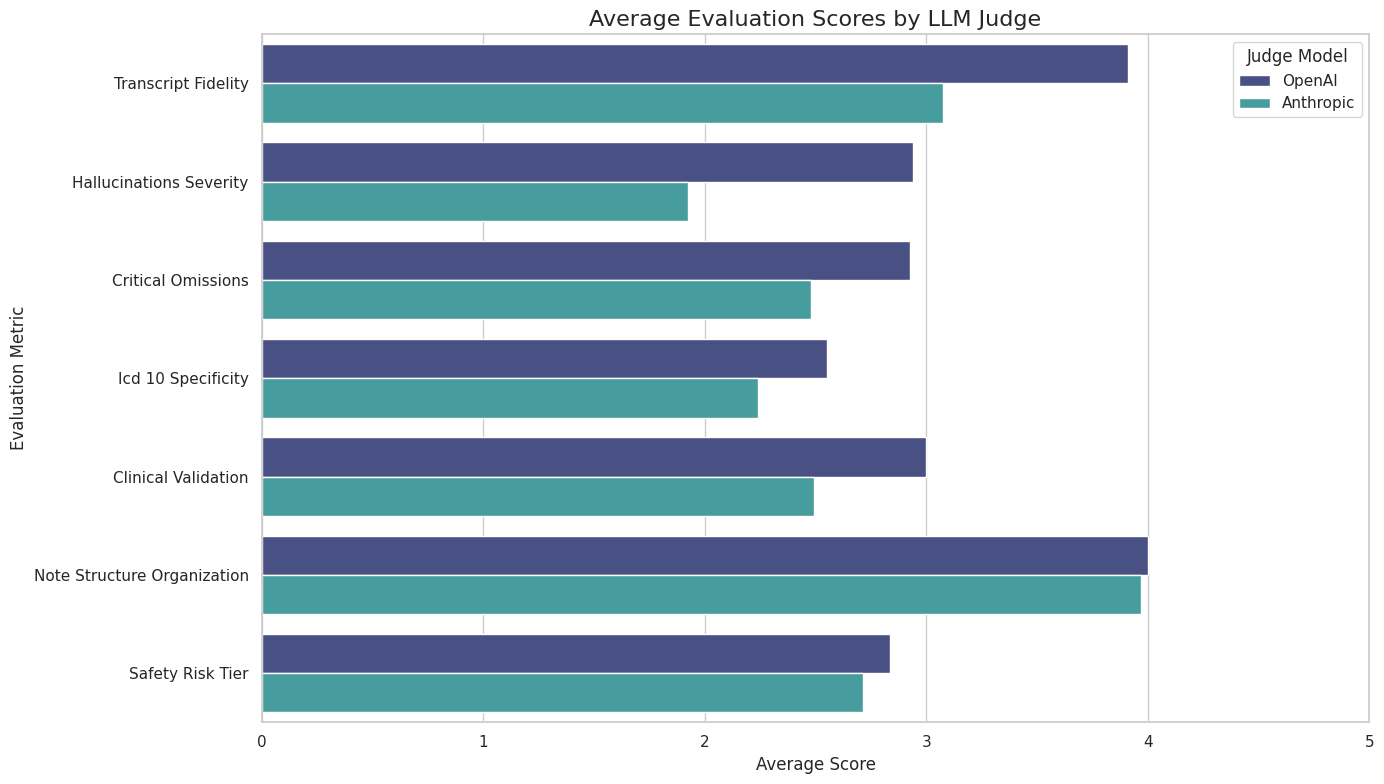

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if 'aggregated_df' not in globals():
    print("⚠️ Error: 'aggregated_df' is not defined. Please run the cell above that evaluates the sample notes and generates 'aggregated_df' before plotting.")
else:
    # Set the visual style
    sns.set_theme(style="whitegrid")

    # Define the metrics to compare
    metrics = [
        'transcript_fidelity_score',
        'hallucinations_severity_score',
        'critical_omissions_score',
        'icd_10_specificity_score',
        'clinical_validation_score',
        'note_structure_organization_score',
        'safety_risk_tier_score'
    ]

    # Filter the dataframe for the metrics
    metrics_df = aggregated_df[['model', 'sample_id'] + metrics]

    # Melt the dataframe for easier plotting with seaborn
    melted_df = pd.melt(metrics_df, id_vars=['model', 'sample_id'], value_vars=metrics, var_name='Metric', value_name='Score')

    # Ensure Score is numeric
    melted_df['Score'] = pd.to_numeric(melted_df['Score'], errors='coerce')

    # Plot 1: Average Scores Comparison
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(x='Score', y='Metric', hue='model', data=melted_df, errorbar=None, palette='mako')
    plt.title('Average Evaluation Scores by LLM Judge', fontsize=16)
    plt.xlabel('Average Score', fontsize=12)
    plt.ylabel('Evaluation Metric', fontsize=12)
    plt.xlim(0, 5) # Assuming max score across metrics is 5

    # Clean up metric names for better readability on y-axis
    labels = [item.get_text().replace('_score', '').replace('_', ' ').title() for item in ax.get_yticklabels()]
    ax.set_yticklabels(labels)

    plt.legend(title='Judge Model')
    plt.tight_layout()
    plt.savefig('llm_judge_comparison_bar.png', dpi=300)
    plt.show()

<Figure size 1600x600 with 0 Axes>

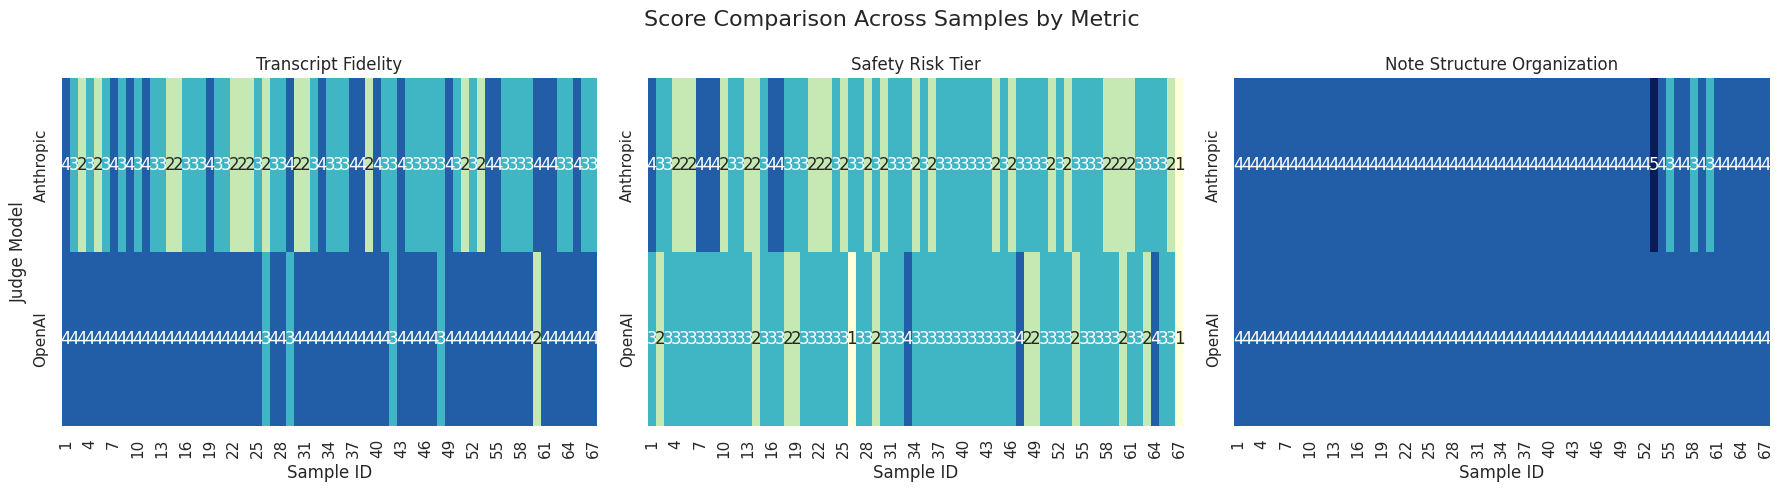

In [12]:
if 'metrics_df' not in globals() or 'aggregated_df' not in globals():
    print("⚠️ Error: Data missing. Please run the evaluation cell and the previous bar chart cell first.")
else:
    # Plot 2: Heatmap of Scores per Sample
    plt.figure(figsize=(16, 6))

    # Pivot the data for heatmap
    pivot_df = metrics_df.pivot(index='model', columns='sample_id', values=metrics)

    # Let's plot just a few key metrics to avoid clutter in the heatmap
    key_metrics = ['transcript_fidelity_score', 'safety_risk_tier_score', 'note_structure_organization_score']

    fig, axes = plt.subplots(1, len(key_metrics), figsize=(18, 5))
    fig.suptitle('Heat Map of Score Comparison Across Samples by Metric', fontsize=16)

    for i, metric in enumerate(key_metrics):
        # Extract data for this metric
        metric_data = aggregated_df.pivot(index='model', columns='sample_id', values=metric)
        # Ensure data is numeric
        metric_data = metric_data.apply(pd.to_numeric, errors='coerce')

        sns.heatmap(metric_data, annot=True, cmap='YlGnBu', ax=axes[i], vmin=1, vmax=5, cbar=False)
        axes[i].set_title(metric.replace('_score', '').replace('_', ' ').title())
        axes[i].set_xlabel('Sample ID')
        axes[i].set_ylabel('Judge Model' if i == 0 else '')

    plt.tight_layout()
    plt.savefig('llm_judge_heatmap.png', dpi=300)
    plt.show()

In [13]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd
import numpy as np

# Ensure aggregated_df exists
if 'aggregated_df' in globals():
    print("--- Inter-Rater Reliability (Cohen's Kappa) ---")
    print("Measures agreement between OpenAI and Anthropic judges.")
    print("Interpretation: <0 (No agreement), 0.0-0.20 (Slight), 0.21-0.40 (Fair), 0.41-0.60 (Moderate), 0.61-0.80 (Substantial), 0.81-1.00 (Almost perfect)\n")
    print("Note: With a very small sample size (e.g., N=3), Kappa scores can be heavily skewed or result in NaN due to lack of variance.\n")

    # Define the key categorical metrics to check agreement on
    kappa_metrics = [
        'transcript_fidelity_score',
        'safety_risk_tier_score',
        'note_structure_organization_score'
    ]

    for metric in kappa_metrics:
        # Extract and align scores for both models as numpy arrays to avoid index mismatches
        openai_scores = aggregated_df[aggregated_df['model'] == 'OpenAI'].sort_values('sample_id')[metric].astype(int).values
        anthropic_scores = aggregated_df[aggregated_df['model'] == 'Anthropic'].sort_values('sample_id')[metric].astype(int).values

        metric_name = metric.replace('_score', '').replace('_', ' ').title()

        # Handle edge cases for zero variance (which causes NaN in standard Kappa calculation)
        if np.array_equal(openai_scores, anthropic_scores) and len(np.unique(openai_scores)) == 1:
            print(f"{metric_name}: Kappa = 1.00 (Perfect agreement, but zero variance across samples)")
            continue

        # Calculate Cohen's Kappa
        kappa = cohen_kappa_score(openai_scores, anthropic_scores)

        if pd.isna(kappa):
            print(f"{metric_name}: Kappa = NaN (Could not calculate due to insufficient score variance)")
        else:
            print(f"{metric_name}: Kappa = {kappa:.2f}")
else:
    print("⚠️ Error: 'aggregated_df' not found. Please run the evaluation cells first.")

--- Inter-Rater Reliability (Cohen's Kappa) ---
Measures agreement between OpenAI and Anthropic judges.
Interpretation: <0 (No agreement), 0.0-0.20 (Slight), 0.21-0.40 (Fair), 0.41-0.60 (Moderate), 0.61-0.80 (Substantial), 0.81-1.00 (Almost perfect)

Note: With a very small sample size (e.g., N=3), Kappa scores can be heavily skewed or result in NaN due to lack of variance.

Transcript Fidelity: Kappa = -0.02
Safety Risk Tier: Kappa = -0.13
Note Structure Organization: Kappa = 0.00


### Interpretation of LLM-as-a-Judge Results (Clinical Context - Full N=67 Dataset)

Evaluating the full ACI-Bench dataset (67 clinical encounters) reveals significant, quantifiable differences in how frontier models behave as clinical auditors. The expanded sample size highlights a stark divergence in model strictness and evaluation philosophy:

**1. Auditor Strictness and Clinical Fact Grounding:**
* **Anthropic (Claude) as a Strict Compliance Auditor:** Across the full dataset, Anthropic consistently acts as a highly conservative judge. It assigns stricter (lower) scores for **Transcript Fidelity**, **Hallucinations**, and **Critical Omissions**. In a clinical setting, Claude functions like a rigid CDI specialist, heavily penalizing any AI-generated text that deviates from or assumes details not explicitly stated in the transcript.
* **OpenAI (GPT-4o-mini) as a Lenient Summarizer:** OpenAI evaluates the notes much more leniently, frequently giving perfect scores for fidelity and safety. It appears to evaluate based on general "clinical plausibility" rather than strict transcript grounding, making it much more forgiving but potentially riskier for catching subtle hallucinations.

**2. Inter-Rater Reliability (Cohen's Kappa):**
* The calculated Cohen's Kappa scores across the 67 notes are strikingly low (near or below 0.0) for metrics like *Transcript Fidelity* and *Safety Risk Tier*. This mathematically proves that the two models have **almost no agreement** in their evaluation standards. Anthropic is consistently finding errors and safety risks that OpenAI completely ignores.

**3. Structural and Stylistic Agreement:**
* Despite disagreeing on factual fidelity, both models show high baseline scores for **Note Structure Organization**. This confirms that the generative AI successfully synthesizes the required Outpatient Note formats (CC, HPI, ROS, etc.), even if the underlying clinical facts are contested.

**Conclusion for Clinical Deployment:**
The full dataset evaluation strongly supports using **Anthropic** if the goal is a strict safety net to catch hallucinations, omissions, and compliance failures before a physician signs the note. The lack of agreement (low Kappa) between the models proves that relying on a lenient model like GPT-4o-mini for clinical auditing risks letting clinically significant errors slip through to the final medical record.

### Future Directions

To further validate and refine this LLM-as-a-Judge evaluation harness, the following next steps are proposed:

**1. Prompt Engineering for Inter-Rater Reliability (IRR):**
*   **Iterative Refinement via Loop Engineering:** Conduct "loop engineering" on the prompts for highly subjective metrics like *Transcript Fidelity* and *Safety Risk Tier*. By analyzing the discrepancies between Anthropic and OpenAI, we can introduce more explicit edge-case examples into the prompt rubrics to tighten agreement.
*   **Chain-of-Thought (CoT) Verification:** Require the LLM judges to output a short rationale *before* providing their final numeric score. This forces the model to ground its decision and often increases inter-model consensus.

**2. Clinician Concordance Study (Human-in-the-Loop):**
*   **Expert Baselines:** Validate the LLM-as-a-Judge outputs against a panel of human clinical documentation experts (e.g., CDI specialists, attending physicians).
*   **Benchmarking AI vs. Human:** Compare the AI judges' scores to the human experts to determine which LLM's scoring profile (OpenAI's generalized approach vs. Anthropic's conservative approach) more accurately reflects true clinical judgment.

**3. Statistical Agreement Analysis:**
*   **Cohen's Kappa:** Formalize the inter-rater reliability between the LLM judges by calculating Cohen's Kappa (or Fleiss' Kappa for >2 judges) and against human judges for categorical metrics. This provides a rigorous quantitative measure of consensus beyond simple score averaging, helping to prove the statistical validity of the automated audit.
*   **Handling Zero-Variance Edge Cases:** Address statistical artifacts (like Cohen's Kappa returning 0.0 or NaN) that occur when an AI judge exhibits zero variance (e.g., universally scoring a '4') across a highly uniform sample set.

**4. Introduce a Severity-Weighted F1 Score:**
*   **NOHARM Study:** Use vetted measures of precision and recall (informed by recent findings in the [NOHARM2](https://arxiv.org/abs/2512.01241) study by Wu, *et al* published in *Nature Science* (2026) to calculate a severity-weighted F1 score. Consider using scales derived from the RAND-UCLA Appropriateness Method (severity-weighted precision or hallucinations) and WHO Harm Severity Definitions (Severity-weighted recall or omission) to introduce more consistency in evaluation of these metrics.

---

## Resources
* [ACI-BENCH dataset](https://arxiv.org/abs/2306.02022)
* [NOHARM2 Study](https://arxiv.org/abs/2512.01241)